<a href="https://colab.research.google.com/github/Skategarg/WorldBank-Data-Set-Analysis/blob/main/WorldBank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2: Colab Lab & Design Sprint #2
## Team: Education Access | Dataset: World Bank Education Indicators
### HCD Phase: **Define** — Cleaning Data & Visualizing Truth

**Today's Mission:** Assess → Clean → Visualize → Tell the Story → Write Your Problem Statement → Build a First (Baseline) Prediction Model

By the end of this notebook you should be able to say:
- [ ] I can describe what "long-format" data means and why this dataset is shaped that way
- [ ] I wrote a Data Audit Report identifying real problems in this dataset
- [ ] I cleaned the data and can justify every decision I made
- [ ] I built 4 publication-quality charts, each with a finding-based title
- [ ] I wrote a 150-word Data Brief a city council member could understand
- [ ] My team wrote a formal Data Problem Statement
- [ ] I built a baseline prediction model and know its accuracy, precision, and recall
- [ ] I can name one thing this dataset **cannot** tell us — and why that matters

---


## Vocabulary Check (before you touch any code)

| Term | Plain-English Meaning |
|---|---|
| **Long format** | Each row is one *observation* of one *variable* — instead of one column per indicator, you get an `indicator` column and a `value` column. One country-year can appear on many rows. |
| **Data Audit Report** | A written list of every quality problem you find in a dataset, *before* you fix anything. |
| **Pipeline** | The ordered set of cleaning steps you run, in order, every time — so your cleaning is repeatable, not one-off guesswork. |
| **Aggregate row** | A row that represents a *group* of countries (like "Arab World" or "Early-demographic dividend"), not a single country. World Bank data mixes these in with real countries. |
| **Baseline model** | The simplest reasonable model you build first, so you have something to compare later, smarter models against. |
| **Threshold** | A cutoff value you choose to turn a number into a category (e.g., "literacy rate ≥ 75% = High"). |

> **Rule of the day:** every cleaning decision, every chart, and every model choice needs one sentence explaining *why* you made it. Code with no explanation gets no credit.


In [ ]:
# Setup — run this first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", None)

print("Libraries loaded.")


Libraries loaded.


---
## STEP 1 — ASSESS: Write a Data Audit Report

**Concept before code:** Before you clean anything, you inspect everything. An audit answers: *What am I actually looking at?* Skipping this step is how people clean away important findings by accident.

Load your team's cleaned-from-raw CSV. (Replace the placeholder URL below with your team's GitHub raw link — Sajid's convention: `worldbank_education_raw.csv`.)


In [ ]:
# importing necessary libraries
import pandas as pd
import requests

indicators = {
    'literacy_rate':     'SE.ADT.LITR.ZS',
    'primary_enrollment': 'SE.PRM.ENRR',
    'secondary_enrollment':'SE.SEC.ENRR',
    'govt_edu_spending':  'SE.XPD.TOTL.GD.ZS',
    'out_of_school_rate': 'SE.PRM.UNER.ZS'
}

frames = []
for name, code in indicators.items():
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?format=json&per_page=5000"
    r = requests.get(url)
    records = r.json()[1]
    if not records:
        continue
    temp = pd.DataFrame([{
        'country': rec['country']['value'],
        'country_code': rec['countryiso3code'],
        'year': rec['date'],
        'value': rec['value'],
        'indicator': name
    } for rec in records if rec['value'] is not None])
    frames.append(temp)

df = pd.concat(frames, ignore_index=True)

# printing the rows and columns of the dataset
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.sample(5)

Shape: 10407 rows × 5 columns


,country,country_code,year,value,indicator
1537,Sub-Saharan Africa (excluding high income),SSA,1989,51.669998,literacy_rate
3851,World,WLD,1980,90.905647,primary_enrollment
1821,Africa Eastern and Southern,AFE,2018,102.624809,primary_enrollment
4493,Belarus,BLR,1980,101.339211,primary_enrollment
3448,Pre-demographic dividend,PRE,2001,80.048714,primary_enrollment


In [ ]:
# Shape and structure
print("Rows, Columns:", df.shape)
df.info()


Rows, Columns: (10407, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10407 entries, 0 to 10406
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       10407 non-null  object 
 1   country_code  10407 non-null  object 
 2   year          10407 non-null  object 
 3   value         10407 non-null  float64
 4   indicator     10407 non-null  object 
dtypes: float64(1), object(4)
memory usage: 406.7+ KB


In [ ]:
# Summary statistics -- remember: this describes the WHOLE 'value' column,
# which mixes THREE different indicators with different units. Keep that in mind
# when you interpret these numbers -- a mean across mixed units is not meaningful yet.
df.describe()


,value
count,10407.000000
mean,59.159759
std,39.341689
min,0.000000
25%,14.134240
50%,66.798828
75%,96.089310
max,164.079819


In [ ]:
# Missing values, column by column
df.isnull().sum()


,0
country,0
country_code,0
year,0
value,0
indicator,0


In [ ]:
# What indicators are actually in this dataset, and how many rows does each have?
df["indicator"].value_counts()


,count
indicator,
primary_enrollment,3058
secondary_enrollment,2883
govt_edu_spending,1884
literacy_rate,1815
out_of_school_rate,767


In [ ]:
# How many unique "countries" are there? Look closely at the names --
# do they all look like real countries to you?
print("Unique country entries:", df["country"].nunique())
sorted(df["country"].unique())[:40]   # first 40, alphabetically


Unique country entries: 75


['Afghanistan',
 'Africa Eastern and Southern',
 'Africa Western and Central',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua and Barbuda',
 'Arab World',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas, The',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Caribbean small states',
 'Central Europe and the Baltics',
 'Early-demographic dividend',
 'East Asia & Pacific',
 'East Asia & Pacific (IDA & IBRD countries)',
 'East Asia & Pacific (excluding high income)',
 'Euro area',
 'Europe & Central Asia',
 'Europe & Central Asia (IDA & IBRD countries)']

### ⚠️ Concept Alert: Aggregate Rows

Look at the sample rows below — do you recognize these as *countries*?

| country | country_code |
|---|---|
| IDA blend | IDB |
| IDA only | IDX |
| Early-demographic dividend | EAR |
| Arab World | ARB |

**These are not countries.** The World Bank bundles *region* and *income-group* summaries (like "Arab World," "Early-demographic dividend," "IDA blend") into the same country list as real countries like "Kenya" or "Peru." If you don't separate these out, your "average across countries" will secretly include averages-of-averages, which distorts every statistic you compute.

**This is not a minor detail — flag it as a real problem in your audit.** Real, individual-country codes are 3 uppercase letters that match [ISO 3166-1 alpha-3](https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3) (e.g., `KEN`, `PER`, `USA`). Aggregate codes tend to be things like `ARB`, `EAR`, `IDB`, `WLD`, `LIC`, `LMY` — group codes, not country codes.


In [ ]:
# Find candidate aggregate rows: codes that are NOT standard 3-letter ISO country codes
# is_aggregate is a starting heuristic -- inspect the output and confirm/adjust by hand.
suspicious = df[["country", "country_code"]].drop_duplicates().sort_values("country")
suspicious


,country,country_code
1683,Afghanistan,AFG
0,Africa Eastern and Southern,AFE
38,Africa Western and Central,AFW
1688,Albania,ALB
1694,Algeria,DZA
...,...,...
1462,Sub-Saharan Africa,SSF
1542,Sub-Saharan Africa (IDA & IBRD countries),TSS
1502,Sub-Saharan Africa (excluding high income),SSA
1582,Upper middle income,


### 📝 Data Audit Report (fill in the blanks)

> **Dataset:** World Bank Education Indicators
> **Shape:** ____ rows × ____ columns
> **Indicators present:** ____________________________
> **Missing values found:** ____ (in which column(s)? ____________)
> **Duplicate rows found:** ____
> **Aggregate ("not a real country") rows found:** ____ — list 3 examples: ____________________
> **Units problem:** the `value` column holds ____ different indicators, each measured in ____________ (e.g., % of population, % of GDP). This means I ______ (can / cannot) directly average `value` across different indicators without first splitting by indicator.
> **My #1 concern about this dataset before I clean it:** ________________________________


---
## STEP 2 — CLEAN: Build a Documented, Justified Pipeline

**Concept before code:** Every cleaning choice is an analytical choice. Dropping a row assumes its absence doesn't distort your story. Keeping an aggregate row assumes it belongs. Write your reasoning as a comment *before* the code that does it — a future reader (including you, in Week 4) should understand *why*, not just *what*.


In [ ]:
# --- Cleaning Step A: Separate real countries from aggregate/region rows ---
# WHY: mixing "Arab World" (a regional average) in with "Jordan" (a real country)
# would double-count the region's influence and mislead any country-level analysis.

# A partial, non-exhaustive list of known World Bank aggregate codes to get you started.
# HINT: inspect the `suspicious` table above and ADD any codes you find that look like
# regions/income groups rather than countries.
known_aggregate_codes = [
    "ARB", "EAR", "EAS", "EAP", "ECA", "ECS", "EMU", "EUU", "FCS",
    "HIC", "HPC", "IBD", "IBT", "IDA", "IDB", "IDX", "LAC", "LCN",
    "LDC", "LIC", "LMC", "LMY", "LTE", "MEA", "MIC", "MNA", "NAC",
    "OED", "OSS", "PRE", "PSS", "PST", "SAS", "SSA", "SSF", "SST",
    "TEA", "TEC", "TLA", "TMN", "TSA", "TSS", "UMC", "WLD"
]

countries_df = df[~df["country_code"].isin(known_aggregate_codes)].copy()
aggregates_df = df[df["country_code"].isin(known_aggregate_codes)].copy()

print("Real-country rows:", countries_df.shape[0])
print("Aggregate rows set aside:", aggregates_df.shape[0])


Real-country rows: 4622
Aggregate rows set aside: 5785


> **Justification:** we are *not deleting* the aggregate rows — we are setting them aside in `aggregates_df`. They can be genuinely useful later (e.g., comparing "Sub-Saharan Africa" trends), just not mixed into country-level statistics. **Document this choice in your own words:** ___________________________________


In [ ]:
# --- Cleaning Step B: Check and handle missing values ---
# WHY: fillna/dropna is an analytical decision -- ask yourself: is this data
# MISSING AT RANDOM, or missing in a pattern (e.g., only certain years, only certain
# indicators)? A pattern is itself a finding, not just noise to remove.

print("Missing values by indicator (countries_df only):")
print(countries_df.groupby("indicator")["value"].apply(lambda s: s.isnull().sum()))

# TODO (tweak this): decide -- for THIS analysis, do you drop rows with missing `value`,
# or keep them and simply exclude them from calculations later?
# HINT: for a long-format dataset like this, dropping rows with a missing `value` is usually
# safest -- you are not deleting a country, only one observation of one indicator-year.
countries_clean = countries_df.dropna(subset=["value"]).copy()
print("\nRows after dropping missing values:", countries_clean.shape[0])


Missing values by indicator (countries_df only):
indicator
govt_edu_spending       0
literacy_rate           0
out_of_school_rate      0
primary_enrollment      0
secondary_enrollment    0
Name: value, dtype: int64

Rows after dropping missing values: 4622


In [ ]:
# --- Cleaning Step C: Check for duplicate rows ---
dupes = countries_clean.duplicated(subset=["country", "year", "indicator"]).sum()
print("Duplicate country-year-indicator rows:", dupes)

countries_clean = countries_clean.drop_duplicates(subset=["country", "year", "indicator"])


Duplicate country-year-indicator rows: 0


In [ ]:
# --- Cleaning Step D: Sanity-check value ranges, indicator by indicator ---
# WHY: literacy_rate and primary_enrollment are PERCENTAGES -- they should fall
# between 0 and 100. A value like -5 or 250 is a red flag, not a real observation.
# govt_edu_spending is measured differently (often % of government budget or % of GDP)
# so do NOT assume it follows the same 0-100 rule without checking its own description.

for ind in countries_clean["indicator"].unique():
    sub = countries_clean.loc[countries_clean["indicator"] == ind, "value"]
    print(f"{ind:>22}: min={sub.min():.2f}  max={sub.max():.2f}  n={len(sub)}")


         literacy_rate: min=16.48  max=100.00  n=390
    primary_enrollment: min=19.72  max=159.81  n=1393
  secondary_enrollment: min=2.28  max=164.08  n=1234
     govt_edu_spending: min=0.94  max=14.72  n=864
    out_of_school_rate: min=0.00  max=77.98  n=741


**Look at your printed ranges above.** Is anything outside the range you'd expect for that unit? If so, decide: is it a data-entry error (drop or investigate), or a legitimate extreme value (keep, but flag in your Data Limitations paragraph)? **Write your decision:** ___________________________________


In [ ]:
# --- Cleaning Step E: Confirm data types ---
countries_clean["year"] = pd.to_numeric(countries_clean["year"], errors="coerce")
countries_clean["value"] = pd.to_numeric(countries_clean["value"], errors="coerce")
countries_clean = countries_clean.dropna(subset=["year", "value"])

countries_clean.dtypes


,0
country,object
country_code,object
year,int64
value,float64
indicator,object


In [ ]:
# --- Verification: prove your cleaning worked ---
assert countries_clean.isnull().sum().sum() == 0, "There are still missing values!"
assert countries_clean.duplicated(subset=["country","year","indicator"]).sum() == 0, "Duplicates remain!"
print("Cleaning verified. Clean shape:", countries_clean.shape)

# Save your cleaned file using the course naming convention
countries_clean.to_csv("education_cleaned_YYYYMMDD.csv", index=False)  # TODO: replace YYYYMMDD
print("Saved.")


Cleaning verified. Clean shape: (4622, 5)
Saved.


### 📝 Data Limitations Paragraph (fill in)

> After cleaning, our dataset represents ____ real countries, across the years ____ to ____, for the indicators: ____________________________. Cleaning could **not** fix ________________________ (e.g., missing years for some countries, no way to know *why* a value is missing). A reader should know that this dataset still cannot tell us ________________________.


---
## STEP 3 — VISUALIZE: 4 Publication-Quality Charts

**Concept before code:** A chart title should state the *finding*, not just the topic. "Literacy Rate by Region" is a label. "Girls' literacy trails boys' by double digits in low-income countries" is a finding. Every chart below needs: a finding-based title, labeled axes with units, and 2 sentences of interpretation underneath.

Because this data is **long-format**, some charts need one indicator at a time (filter first), and some comparisons need the data reshaped **wide** (one column per indicator) using `pivot_table`. You'll practice both.


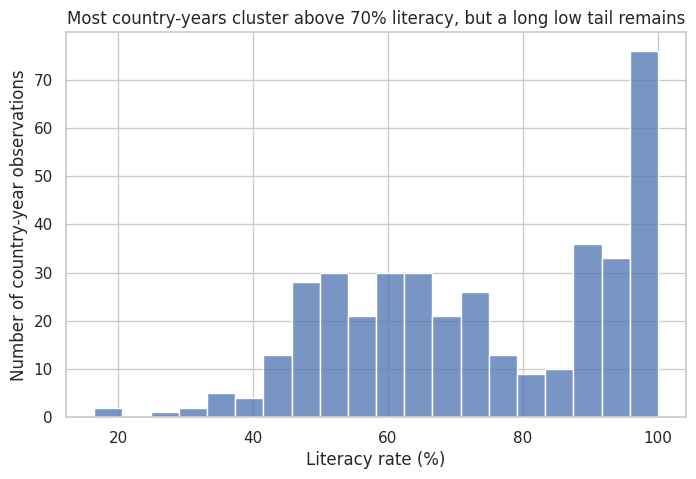

In [ ]:
# Chart 1 — Histogram: distribution of literacy_rate values across all country-years
# HINT TO TWEAK: try bins=10, 20, and 30 -- which bin width tells the clearest story
# without looking noisy or hiding real gaps? Pick the one you can best justify.

lit = countries_clean[countries_clean["indicator"] == "literacy_rate"]

plt.figure(figsize=(8,5))
sns.histplot(lit["value"], bins=20, color="#4C72B0")
plt.title("Most country-years cluster above 70% literacy, but a long low tail remains")
plt.xlabel("Literacy rate (%)")
plt.ylabel("Number of country-year observations")
plt.show()


**Interpretation (fill in, 2 sentences):** ________________________________________________________________


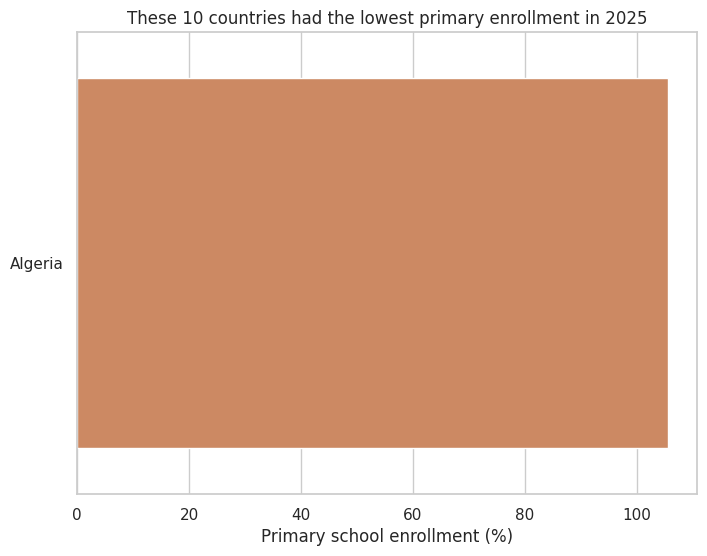

In [ ]:
# Chart 2 — Bar chart: which countries have the LOWEST recent primary_enrollment?
# HINT TO TWEAK: change `n_countries` and the `year` filter. Does the ranking change much
# if you use the most recent year available for each country instead of one fixed year?

n_countries = 10
enroll = countries_clean[countries_clean["indicator"] == "primary_enrollment"]
latest_year = enroll["year"].max()
latest_enroll = enroll[enroll["year"] == latest_year]

lowest = latest_enroll.sort_values("value").head(n_countries)

plt.figure(figsize=(8,6))
sns.barplot(data=lowest, y="country", x="value", color="#DD8452")
plt.title(f"These {n_countries} countries had the lowest primary enrollment in {int(latest_year)}")
plt.xlabel("Primary school enrollment (%)")
plt.ylabel("")
plt.show()


**Interpretation (fill in, 2 sentences):** ________________________________________________________________


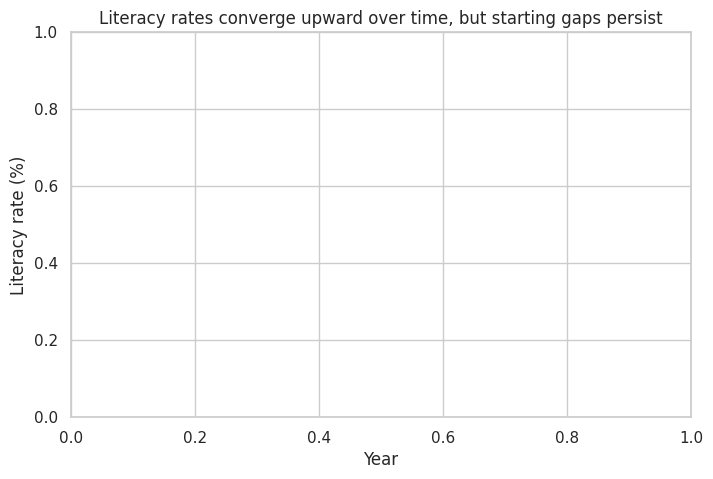

In [ ]:
# Chart 3 — Line chart: how has literacy_rate changed over time for a few countries?
# HINT TO TWEAK: swap out the countries in `countries_to_plot` for ones your team cares about.
# Do NOT plot more than ~5 lines at once -- it becomes unreadable.

countries_to_plot = ["Kenya", "Peru", "India"]   # TODO: change to countries in YOUR cleaned data
subset = lit[lit["country"].isin(countries_to_plot)].sort_values("year")

plt.figure(figsize=(8,5))
sns.lineplot(data=subset, x="year", y="value", hue="country", marker="o")
plt.title("Literacy rates converge upward over time, but starting gaps persist")
plt.xlabel("Year")
plt.ylabel("Literacy rate (%)")
plt.show()


**Interpretation (fill in, 2 sentences):** ________________________________________________________________


/tmp/ipykernel_1625/2410591024.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=region_data, x="country", y="value", palette="colorblind")


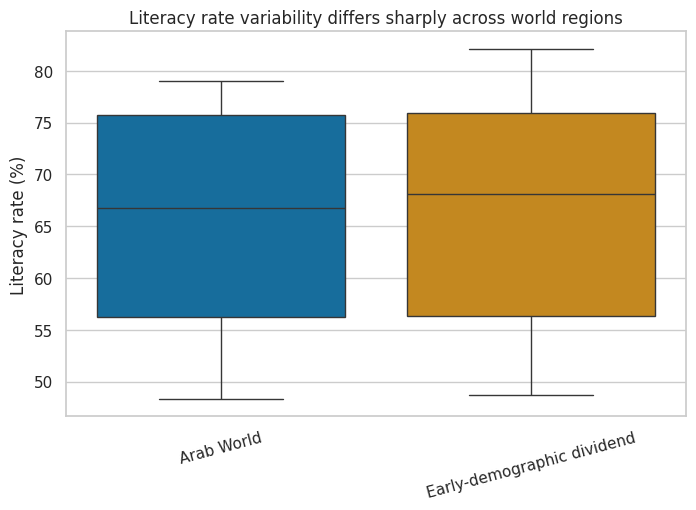

In [ ]:
# Chart 4 — Box plot: comparing an indicator ACROSS the aggregate/region groups we set aside
# This is where `aggregates_df` becomes useful again -- comparing income-group regions.
# HINT TO TWEAK: try switching indicator to "govt_edu_spending" -- does the spread change?

region_names = ["Arab World", "Early-demographic dividend"]  # TODO: pick 2-4 from aggregates_df
region_data = aggregates_df[
    (aggregates_df["indicator"] == "literacy_rate") &
    (aggregates_df["country"].isin(region_names))
]

plt.figure(figsize=(8,5))
sns.boxplot(data=region_data, x="country", y="value", palette="colorblind")
plt.title("Literacy rate variability differs sharply across world regions")
plt.xlabel("")
plt.ylabel("Literacy rate (%)")
plt.xticks(rotation=15)
plt.show()

**Interpretation (fill in, 2 sentences):** ________________________________________________________________

**Challenge-an-assumption checkpoint:** which of your 4 charts above surprised you, or pushed back against something you assumed before looking at the data? Name it: ________________________________


---
## STEP 4 — STORY: Write Your Data Brief

**Task:** In exactly around 150 words, summarize your **3 most important findings** in plain language a city council member (no data background) could understand and act on. No jargon like "R-squared" or "p-value" — just what you found and why it matters to real people.


### 📝 Data Brief (~150 words)

> _Write your Data Brief here. Delete this instruction line when you start._


---
## HCD Design Sprint #2 — Data Problem Statement

**Task (team):** Fill in every blank below with specifics from *your* cleaned dataset. Vague answers ("the data is interesting") will be sent back for revision.


### 📝 Data Problem Statement (team, fill in together)

> Our investigation asks: **[specific, answerable question]**
>
> The dataset we are using is **[name, source, year(s) collected, unit of analysis]**.
>
> The key variable we are analyzing is **[variable name, what it measures, its range and units]**.
>
> Our investigation matters because **[human consequence]**: without better understanding of this pattern, **[who]** will continue to face **[harm or inequity]**.
>
> We define a meaningful finding as **[specific threshold or pattern that would warrant a policy recommendation]**.


---
## STEP 6 — BASELINE: Your First Prediction Model

**Concept before code:** A *baseline* model is not meant to be your best model — it's the simplest reasonable attempt, so you have a number to beat later. Today we turn a continuous indicator into a Yes/No category (a "binary target"), then see if other indicators can predict it.

### ⚠️ Honest Flag Before We Start

This dataset, as structured (`country`, `country_code`, `year`, `value`, `indicator`), has **no demographic column** — no gender, no urban/rural split, no income bracket for individuals. That means **today's baseline model cannot be fairness-checked across demographic groups**, which Week 4 will require.

**This is a real limitation, not a detail to skip past.** Two honest paths forward for your team before Week 4:
1. **Merge in World Bank country metadata** (a separate file with `Region` and `IncomeGroup` per country) — this gives you a *group-level* fairness dimension (e.g., "does the model perform worse for low-income-region countries?").
2. If no demographic-style column can be justified, your team should say so plainly in your Model Evaluation Report rather than forcing a fairness claim the data can't support.

For today, we build the baseline classifier. Group-level fairness comes once metadata is merged in.


In [ ]:
# Reshape long -> wide: one row per (country, year), one column per indicator.
# WHY: a model needs a table where each ROW is one example and each COLUMN is one feature.
# Long format can't be fed to a classifier directly.

wide = countries_clean.pivot_table(
    index=["country", "year"],
    columns="indicator",
    values="value"
).reset_index()

wide = wide.dropna()  # keep only country-years where ALL three indicators are present
print("Wide-format rows usable for modeling:", wide.shape[0])
wide.head()


Wide-format rows usable for modeling: 127


indicator,country,year,govt_edu_spending,literacy_rate,out_of_school_rate,primary_enrollment,secondary_enrollment
182,Albania,2001,3.341990,98.709999,3.113460,109.200050,72.484573
192,Albania,2011,3.178813,96.849998,4.502014,101.580274,95.470528
193,Albania,2012,3.295340,97.250000,2.833544,102.067361,97.608612
198,Albania,2017,3.546730,98.809998,0.687000,105.414971,97.574370
204,Albania,2023,3.091530,97.680000,10.865323,93.713812,96.136877


In [ ]:
# Create the binary target: is literacy_rate "High" or "Low"?
# HINT TO TWEAK: we use the MEDIAN as the cutoff below, which guarantees a roughly
# balanced 50/50 split. Try changing threshold to a fixed value like 75 instead --
# does your class balance become uneven? Why might that matter for accuracy?

threshold = wide["literacy_rate"].median()   # TODO: try a fixed number instead, e.g. 75
wide["literacy_high"] = (wide["literacy_rate"] >= threshold).astype(int)

print(f"Threshold used: {threshold:.1f}%")
print(wide["literacy_high"].value_counts(normalize=True))


Threshold used: 91.5%
literacy_high
1    0.503937
0    0.496063
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Features: everything EXCEPT the target and the identifying columns
feature_cols = ["primary_enrollment", "govt_edu_spending"]  # TODO: try adding "year"
X = wide[feature_cols]
y = wide["literacy_high"]

# HINT TO TWEAK: try test_size=0.3 instead of 0.2 -- does performance change much?
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# k-NN is distance-based -- features must be on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train rows:", len(X_train), " Test rows:", len(X_test))


Train rows: 101  Test rows: 26


In [ ]:
# --- Baseline Model A: Logistic Regression ---
logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)
logreg_preds = logreg.predict(X_test_scaled)

print("=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, logreg_preds), 3))
print(classification_report(y_test, logreg_preds))
print("Confusion matrix:\n", confusion_matrix(y_test, logreg_preds))


=== Logistic Regression ===
Accuracy: 0.692
              precision    recall  f1-score   support

           0       0.73      0.62      0.67        13
           1       0.67      0.77      0.71        13

    accuracy                           0.69        26
   macro avg       0.70      0.69      0.69        26
weighted avg       0.70      0.69      0.69        26

Confusion matrix:
 [[ 8  5]
 [ 3 10]]


In [ ]:
# --- Baseline Model B: k-Nearest Neighbors ---
# HINT TO TWEAK: try k = 3, 5, 7, 11. Small k = noisier/more overfit,
# large k = smoother/more underfit. Which k gives the best TEST accuracy (not train)?

k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train)
knn_preds = knn.predict(X_test_scaled)

print(f"=== k-NN (k={k}) ===")
print("Accuracy:", round(accuracy_score(y_test, knn_preds), 3))
print(classification_report(y_test, knn_preds))
print("Confusion matrix:\n", confusion_matrix(y_test, knn_preds))


=== k-NN (k=5) ===
Accuracy: 0.654
              precision    recall  f1-score   support

           0       0.75      0.46      0.57        13
           1       0.61      0.85      0.71        13

    accuracy                           0.65        26
   macro avg       0.68      0.65      0.64        26
weighted avg       0.68      0.65      0.64        26

Confusion matrix:
 [[ 6  7]
 [ 2 11]]


In [ ]:
# --- Compare both baselines side by side ---
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", f"k-NN (k={k})"],
    "Accuracy": [accuracy_score(y_test, logreg_preds), accuracy_score(y_test, knn_preds)]
})
comparison


,Model,Accuracy
0,Logistic Regression,0.692308
1,k-NN (k=5),0.653846


### 📝 Baseline Recommendation (fill in)

> Between our two baseline models, **[model name]** performed better on **[metric]**, because ________________________________.
>
> The most important thing to remember about *both* of these models: they were trained on **[N]** countries with complete data for all three indicators — countries with missing data were silently dropped. **Who might be missing from that training set, and why does that matter for a "prediction" this model makes about them?** ________________________________
>
> Before this model could be used to check for demographic fairness (Week 4), our team still needs to: ________________________________


---
## Data Journal — Exit Ticket

Answer in your Data Journal (not here):
1. What dataset or technique did I work with today?
2. What pattern or anomaly surprised me?
3. Who is represented in this data — and who is invisible?
4. What would an ethical data scientist do with what I found today?
